# BIG vs SMALL snowfall comparison
This notebook loads **both** cases (`big` and `small`) and produces plots as **left/right subfigures**:
- **Left = BIG snowfall**
- **Right = SMALL snowfall**

It also includes the **lowest layers** diagnostics and the **common active layers** analyses (HS and SWE), also split left/right.

Assumptions:
- You are running this notebook from `.../R_comparisson/output` (or you update `OUT_ROOT`).
- The NetCDF paths match your folder structure.


In [1]:
# Imports
from pathlib import Path
import numpy as np
import pandas as pd
import xarray as xr

import matplotlib as mpl
import matplotlib.pyplot as plt


## 0) Paths and case configuration (loads both cases)

In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

# Project root = directory where this notebook lives
PROJECT_ROOT = Path.cwd()

CASE_PATHS = {
    "big": {
        "dsnow_nc":  PROJECT_ROOT / "output" / "big_snowfall" / "_dsnow_layers_synthetic_big_snowfall_100days.nc",
        "hs2swe_nc": PROJECT_ROOT / "output" / "big_snowfall" / "_hs2swe_layers_synthetic_big_snowfall_100days.nc",
    },
    "small": {
        "dsnow_nc":  PROJECT_ROOT / "output" / "small_snowfall" / "_dsnow_layers_synthetic_small_snowfall_100days.nc",
        "hs2swe_nc": PROJECT_ROOT / "output" / "small_snowfall" / "_hs2swe_layers_synthetic_small_snowfall_100days.nc",
    },
}



# Safety check
for k in ["big", "small"]:
    print(f"\n{k.upper()} case paths:")
    print("  DSNOW :", CASE_PATHS[k]["dsnow_nc"])
    print("  HS2SWE:", CASE_PATHS[k]["hs2swe_nc"])

    if not CASE_PATHS[k]["dsnow_nc"].exists():
        raise FileNotFoundError(CASE_PATHS[k]["dsnow_nc"])
    if not CASE_PATHS[k]["hs2swe_nc"].exists():
        raise FileNotFoundError(CASE_PATHS[k]["hs2swe_nc"])

print("\nAll required files found.")


BIG case paths:
  DSNOW : /Users/jakobwerkgarner/code/mt_dsnow/model_diff/R_comparisson/output/big_snowfall/_dsnow_layers_synthetic_big_snowfall_100days.nc
  HS2SWE: /Users/jakobwerkgarner/code/mt_dsnow/model_diff/R_comparisson/output/big_snowfall/_hs2swe_layers_synthetic_big_snowfall_100days.nc

SMALL case paths:
  DSNOW : /Users/jakobwerkgarner/code/mt_dsnow/model_diff/R_comparisson/output/small_snowfall/_dsnow_layers_synthetic_small_snowfall_100days.nc
  HS2SWE: /Users/jakobwerkgarner/code/mt_dsnow/model_diff/R_comparisson/output/small_snowfall/_hs2swe_layers_synthetic_small_snowfall_100days.nc

All required files found.


## 1) Helper functions (as in your script)

In [3]:
def as_time_layer(da: xr.DataArray) -> np.ndarray:
    """Return numpy array shaped (time, layer) regardless of original dim order."""
    if tuple(da.dims) == ("time", "layer"):
        return da.values
    if tuple(da.dims) == ("layer", "time"):
        return np.swapaxes(da.values, 0, 1)
    raise ValueError(f"Unexpected dims for {da.name}: {da.dims}")

def flatten_nonzero(da: xr.DataArray) -> np.ndarray:
    """Flatten all time×layer values, drop NaN and zeros."""
    a = as_time_layer(da).ravel()
    a = a[np.isfinite(a)]
    a = a[a != 0]
    return a

def stats_table(values: np.ndarray) -> pd.Series:
    """Basic overview stats for 1D values."""
    v = np.asarray(values)
    v = v[np.isfinite(v)]
    if v.size == 0:
        return pd.Series(dtype=float)
    return pd.Series({
        "count": v.size,
        "mean": float(np.mean(v)),
        "std": float(np.std(v)),
        "min": float(np.min(v)),
        "p25": float(np.percentile(v, 25)),
        "median": float(np.percentile(v, 50)),
        "p75": float(np.percentile(v, 75)),
        "max": float(np.max(v)),
    })

def compare_stats(ds_a, ds_b, var):
    """Return a 2-column stats table for variable var from ds_a and ds_b."""
    a = stats_table(flatten_nonzero(ds_a[var]))
    b = stats_table(flatten_nonzero(ds_b[var]))
    return pd.concat([a.rename(f"ΔSNOW.{var}"), b.rename(f"HS2SWE.{var}")], axis=1)

def total_over_layers(ds, var):
    A = as_time_layer(ds[var])
    return np.nansum(A, axis=1)

def get_time_labels(ds):
    """Read timestamps attribute (comma-separated) if present; else use indices."""
    ts = ds.attrs.get("timestamps", None)
    if ts is None:
        return np.arange(ds.dims["time"]).astype(str)
    return np.array([s.strip() for s in ts.split(",")])

def first_nonzero_idx(col):
    idx = np.where(np.isfinite(col) & (col > 0))[0]
    return idx[0] if idx.size else np.nan


## 2) Load and prepare one case (wraps your existing logic)

In [4]:
def prepare_case(case_key: str):
    DSNOW_NC  = CASE_PATHS[case_key]["dsnow_nc"]
    HS2SWE_NC = CASE_PATHS[case_key]["hs2swe_nc"]

    # ---- load
    ds_dsnow  = xr.open_dataset(DSNOW_NC)
    ds_hs2swe = xr.open_dataset(HS2SWE_NC)

    snowpack = None  # enable/attach if you want; keep None by default

    # ---- HS2SWE: HS cm -> m, swe = RHO*HS, SWE total
    ds_hs2swe = ds_hs2swe.assign(HS=ds_hs2swe["HS"] / 100.0)
    ds_hs2swe = ds_hs2swe.assign(swe=ds_hs2swe["RHO"] * ds_hs2swe["HS"])
    ds_hs2swe["SWE"] = ds_hs2swe["swe"].sum(dim="layer")

    # ---- ΔSNOW: alias swe, compute RHO = swe/HS
    ds_dsnow = ds_dsnow.assign(swe=ds_dsnow["SWE_layers"])
    hs = ds_dsnow["HS"]
    swe = ds_dsnow["swe"]
    rho_ds = xr.where((hs > 0) & np.isfinite(hs) & np.isfinite(swe), swe / hs, np.nan)
    ds_dsnow = ds_dsnow.assign(RHO=rho_ds)

    # ---- time axis
    if snowpack is not None:
        time_axis = pd.to_datetime(snowpack["timestamp"])
    else:
        n_time = min(ds_dsnow.sizes["time"], ds_hs2swe.sizes["time"])
        time_axis = pd.date_range(start="2024-01-01", periods=n_time, freq="D")

    n = min(len(time_axis), ds_dsnow.sizes["time"], ds_hs2swe.sizes["time"])
    time_axis = time_axis[:n]

    # ---- common arrays for some plots
    HS_ds = as_time_layer(ds_dsnow["HS"]).astype(float)
    HS_hs = as_time_layer(ds_hs2swe["HS"]).astype(float)

    T = min(len(time_axis), HS_ds.shape[0], HS_hs.shape[0])
    HS_ds = np.where(np.isfinite(HS_ds[:T]), HS_ds[:T], 0.0)
    HS_hs = np.where(np.isfinite(HS_hs[:T]), HS_hs[:T], 0.0)

    L_ds = HS_ds.shape[1]
    L_hs = HS_hs.shape[1]
    L_max = max(L_ds, L_hs)

    time_labels = get_time_labels(ds_dsnow)

    return {
        "case": case_key,
        "ds_dsnow": ds_dsnow,
        "ds_hs2swe": ds_hs2swe,
        "snowpack": snowpack,
        "time_axis": time_axis,
        "time_labels": time_labels,
        "n": n,
        "T": T,
        "HS_ds": HS_ds,
        "HS_hs": HS_hs,
        "L_max": L_max,
    }

cases = {k: prepare_case(k) for k in ["big", "small"]}
print("Prepared cases:", list(cases.keys()))


Prepared cases: ['big', 'small']


## 3) Stats per case

In [5]:
for k in ["big", "small"]:
    print(f"\n\n==================== CASE: {k.upper()} ====================")
    ds_dsnow  = cases[k]["ds_dsnow"]
    ds_hs2swe = cases[k]["ds_hs2swe"]

    print("\n=== HS stats (time×layer, NaN + zeros removed) ===")
    print(compare_stats(ds_dsnow, ds_hs2swe, "HS"))

    print("\n=== RHO stats (time×layer, NaN + zeros removed) ===")
    print(compare_stats(ds_dsnow, ds_hs2swe, "RHO"))

    print("\n=== OVB stats (time×layer, NaN + zeros removed) ===")
    print(compare_stats(ds_dsnow, ds_hs2swe, "OVB"))




==================== CASE: BIG ====================

=== HS stats (time×layer, NaN + zeros removed) ===
          ΔSNOW.HS   HS2SWE.HS
count   750.000000  393.000000
mean      0.076927    0.146788
std       0.091506    0.144681
min       0.001829    0.000878
p25       0.017605    0.022376
median    0.042585    0.123083
p75       0.102650    0.203602
max       0.837689    0.791645

=== RHO stats (time×layer, NaN + zeros removed) ===
         ΔSNOW.RHO   HS2SWE.RHO
count   750.000000  1045.000000
mean    328.030038   265.223082
std     109.662536   142.553814
min      81.194170   113.700000
p25     247.418791   113.700000
median  401.258800   237.049312
p75     401.258800   371.957775
max     401.258800   571.600000

=== OVB stats (time×layer, NaN + zeros removed) ===
         ΔSNOW.OVB  HS2SWE.OVB
count   750.000000  568.000000
mean    112.407073   85.462694
std      69.699296   56.555033
min       2.983908    0.191746
p25      44.397043   31.045633
median  123.684539   88.828996
p75 

## 4) Plot: HS stacked by layer color (2x2 layout)
Top row: ΔSNOW, bottom row: HS2SWE

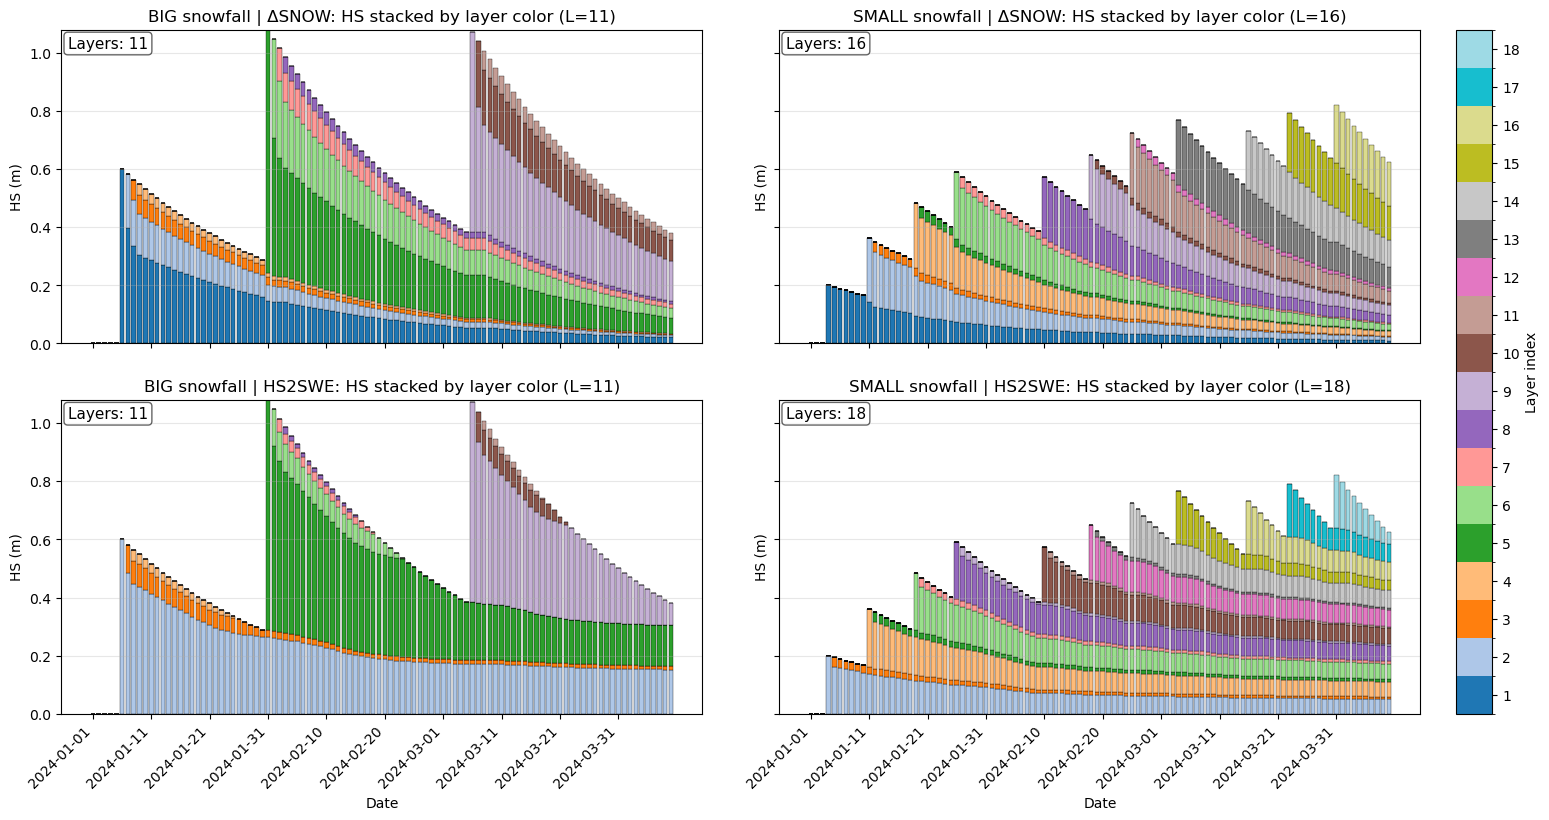

In [6]:
col_titles = {"big": "BIG snowfall", "small": "SMALL snowfall"}

L_max_global = max(cases["big"]["L_max"], cases["small"]["L_max"])
base_cmap = mpl.colormaps["tab20"]
colors = base_cmap(np.linspace(0, 1, L_max_global))
cmap = mpl.colors.ListedColormap(colors)
layer_colors = [colors[i] for i in range(L_max_global)]

fig, axes = plt.subplots(2, 2, figsize=(18, 9), sharex="col", sharey="row")

for c, k in enumerate(["big", "small"]):
    time_axis = cases[k]["time_axis"]
    T = cases[k]["T"]
    HS_ds = cases[k]["HS_ds"]
    HS_hs = cases[k]["HS_hs"]

    # total number of layers in each model for this case
    L_ds_case = HS_ds.shape[1]
    L_hs_case = HS_hs.shape[1]

    axes[0, c].set_title(f"{col_titles[k]} | ΔSNOW: HS stacked by layer color (L={L_ds_case})")
    axes[1, c].set_title(f"{col_titles[k]} | HS2SWE: HS stacked by layer color (L={L_hs_case})")

    for r, (ax, H) in enumerate([(axes[0, c], HS_ds), (axes[1, c], HS_hs)]):
        x = np.arange(T)
        bottom = np.zeros(T)

        for j in range(H.shape[1]):
            hj = H[:, j]
            if np.allclose(hj, 0.0):
                continue
            ax.bar(
                x, hj, bottom=bottom,
                color=layer_colors[j],
                edgecolor="black",
                linewidth=0.25
            )
            bottom += hj

        ax.set_ylabel("HS (m)")
        ax.grid(True, axis="y", alpha=0.3)

        # also print layer count inside each subplot (top-left)
        L_here = H.shape[1]
        ax.text(
            0.01, 0.98, f"Layers: {L_here}",
            transform=ax.transAxes,
            ha="left", va="top",
            fontsize=11,
            bbox=dict(facecolor="white", edgecolor="black", alpha=0.6, boxstyle="round,pad=0.25")
        )

    step = max(1, T // 10)
    ticks = np.arange(0, T, step)
    axes[1, c].set_xticks(ticks)
    axes[1, c].set_xticklabels(
        time_axis[:T][ticks].strftime("%Y-%m-%d"),
        rotation=45, ha="right"
    )
    axes[1, c].set_xlabel("Date")

bounds = np.arange(0.5, L_max_global + 1.5, 1)
norm = mpl.colors.BoundaryNorm(bounds, cmap.N)
sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
tick_step = max(1, L_max_global // 10)

fig.subplots_adjust(right=0.88, bottom=0.12, wspace=0.12, hspace=0.18)
cax = fig.add_axes([0.90, 0.12, 0.02, 0.76])
cbar = fig.colorbar(sm, cax=cax, ticks=np.arange(1, L_max_global + 1, tick_step))
cbar.set_label("Layer index")
plt.show()

## 5) Plot: Total HS (1x2)

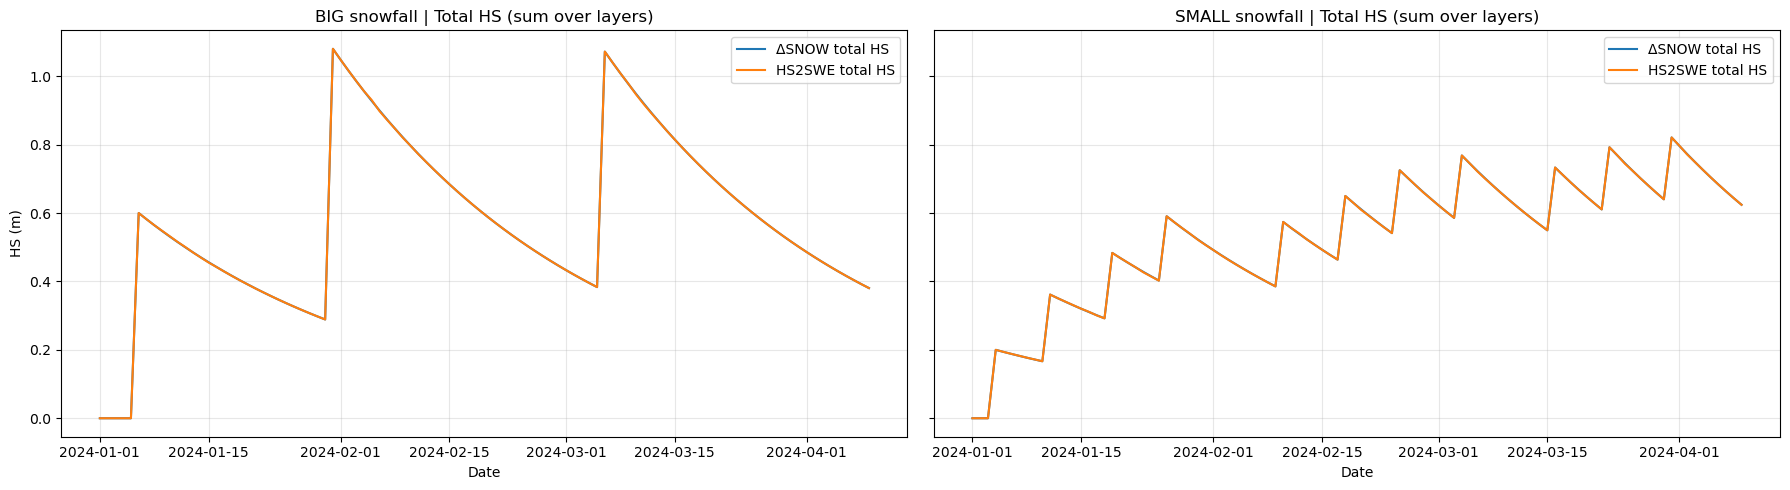

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5), sharey=True)

for ax, k in zip(axes, ["big", "small"]):
    ds_dsnow  = cases[k]["ds_dsnow"]
    ds_hs2swe = cases[k]["ds_hs2swe"]
    time_axis = cases[k]["time_axis"]
    n = cases[k]["n"]

    hs_total_dsnow = total_over_layers(ds_dsnow, "HS")
    hs_total_hs2   = total_over_layers(ds_hs2swe, "HS")

    ax.plot(time_axis[:n], hs_total_dsnow[:n], label="ΔSNOW total HS")
    ax.plot(time_axis[:n], hs_total_hs2[:n], label="HS2SWE total HS")
    ax.set_title(f"{col_titles[k]} | Total HS (sum over layers)")
    ax.set_xlabel("Date")
    ax.grid(True, alpha=0.3)
    ax.legend()

axes[0].set_ylabel("HS (m)")
plt.tight_layout()
plt.show()


## 6) Plot: Total SWE (1x2)

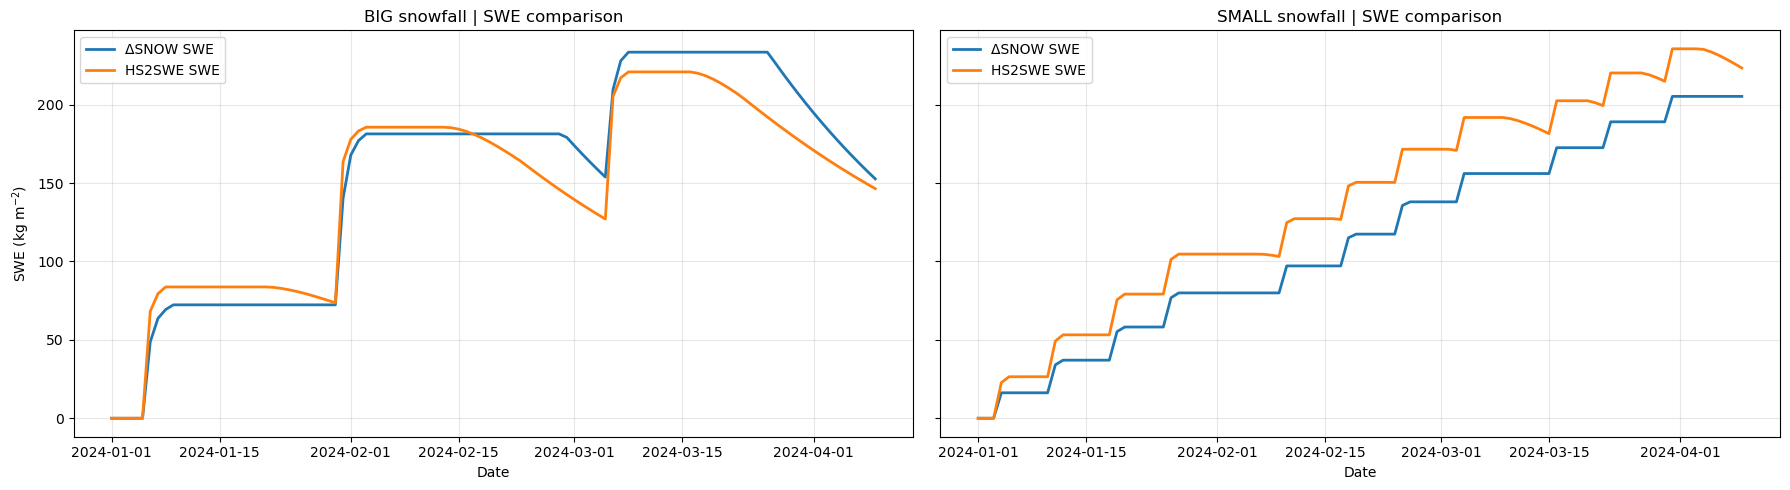

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5), sharey=True)

for ax, k in zip(axes, ["big", "small"]):
    ds_dsnow  = cases[k]["ds_dsnow"]
    ds_hs2swe = cases[k]["ds_hs2swe"]
    time_axis = cases[k]["time_axis"]
    n = cases[k]["n"]
    snowpack = cases[k]["snowpack"]

    swe_dsnow = np.asarray(ds_dsnow["SWE"].values, dtype=float)
    swe_hs2   = np.asarray(ds_hs2swe["SWE"].values, dtype=float)

    ax.plot(time_axis[:n], swe_dsnow[:n], label="ΔSNOW SWE", linewidth=2)
    ax.plot(time_axis[:n], swe_hs2[:n], label="HS2SWE SWE", linewidth=2)

    if snowpack is not None:
        swe_obs = np.asarray(snowpack["SWE"].values, dtype=float)
        n_obs = min(len(swe_obs), n)
        ax.plot(time_axis[:n_obs], swe_obs[:n_obs],
                label="SNOWPACK SWE", linewidth=2, linestyle="--")

    ax.set_title(f"{col_titles[k]} | SWE comparison")
    ax.set_xlabel("Date")
    ax.grid(True, alpha=0.3)
    ax.legend()

axes[0].set_ylabel("SWE (kg m$^{-2}$)")
plt.tight_layout()
plt.show()


/var/folders/r5/2d5m4_zn37d74npwnbfcpcdh0000gn/T/ipykernel_3163/733635243.py:32: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl.cm.get_cmap(cmap_name)
/var/folders/r5/2d5m4_zn37d74npwnbfcpcdh0000gn/T/ipykernel_3163/733635243.py:32: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl.cm.get_cmap(cmap_name)
/var/folders/r5/2d5m4_zn37d74npwnbfcpcdh0000gn/T/ipykernel_3163/733635243.py:32: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl.cm.get

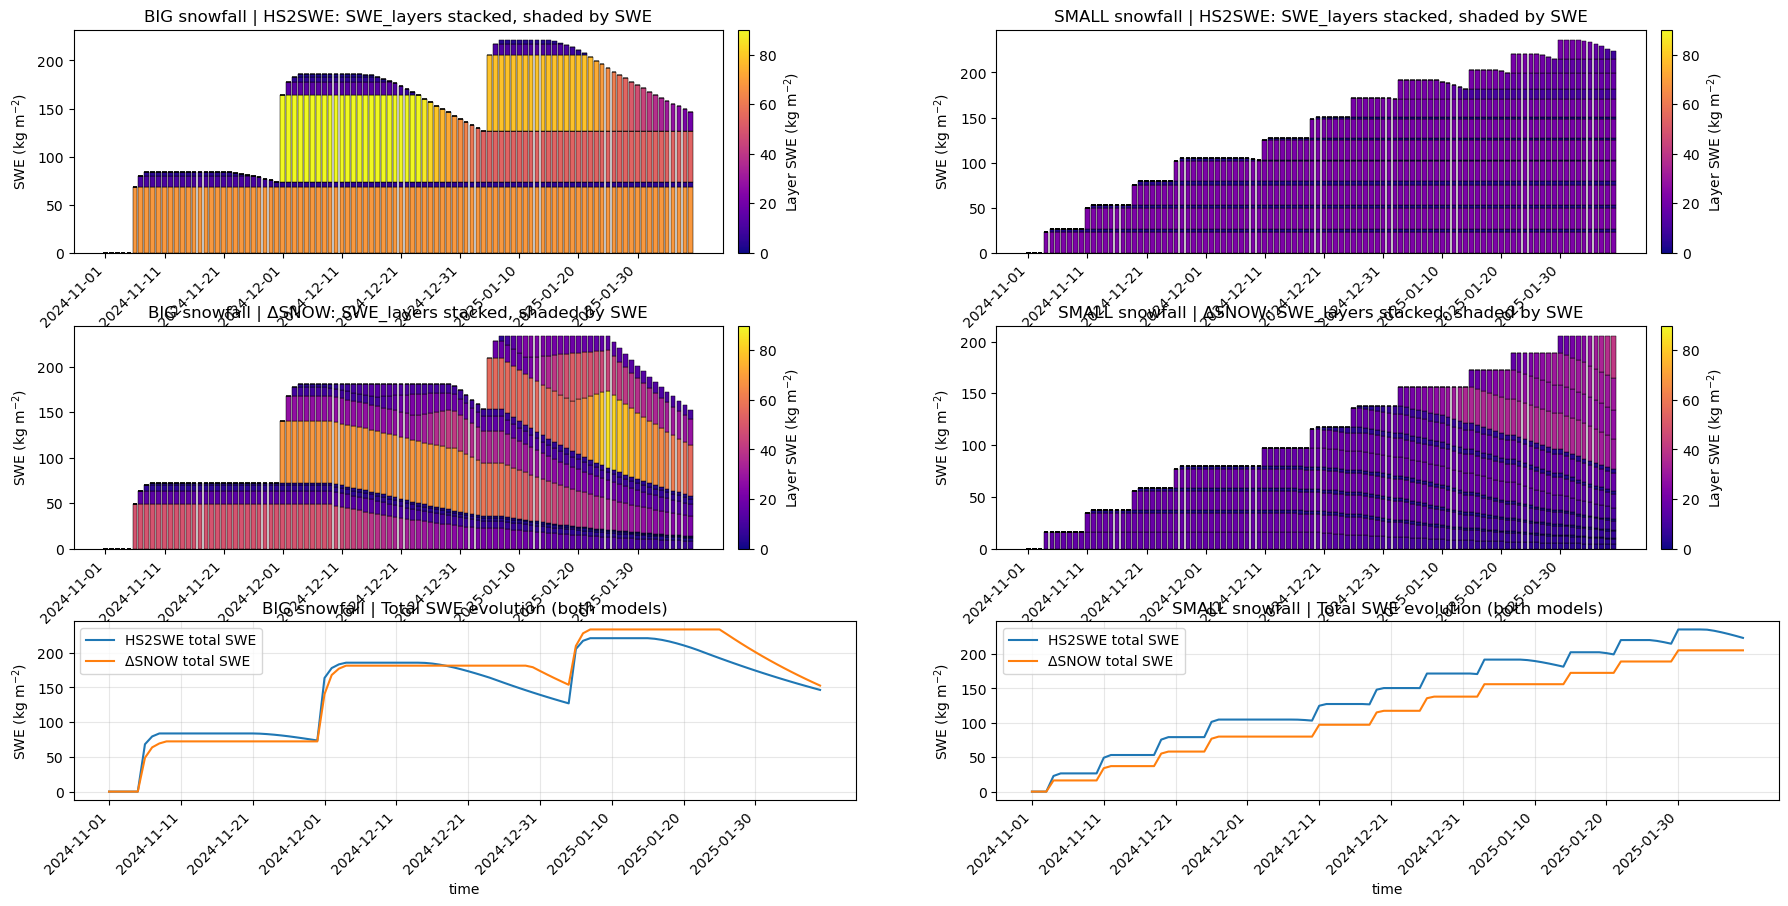

In [9]:
# ============================================================
# 8) STACKED SWE LAYERS (shaded by SWE) + TOTAL SWE LINES BELOW
# BIG (left) vs SMALL (right), each column has 3 rows:
#   row 1: HS2SWE stacked SWE_layers
#   row 2: ΔSNOW stacked SWE_layers
#   row 3: total SWE lines (both models)
# ============================================================

def stacked_bar(ax, heights_tl, shade_tl, title, ylabel, time_labels,
                cmap_name="viridis", edgecolor="black", linewidth=0.35,
                vmin=None, vmax=None):
    import matplotlib as mpl
    import numpy as np

    H = np.array(heights_tl, dtype=float)
    S = np.array(shade_tl, dtype=float)

    T, L = H.shape
    x = np.arange(T)

    H = np.where(np.isfinite(H), H, 0.0)
    S = np.where(np.isfinite(S), S, np.nan)

    if vmin is None:
        vmin = np.nanmin(S)
    if vmax is None:
        vmax = np.nanmax(S)
    if (not np.isfinite(vmin)) or (not np.isfinite(vmax)) or (vmin == vmax):
        vmin, vmax = 0.0, 1.0

    norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
    cmap = mpl.cm.get_cmap(cmap_name)

    bottom = np.zeros(T)
    for j in range(L):
        hj = H[:, j]
        if np.allclose(hj, 0.0):
            continue
        colors = cmap(norm(S[:, j]))
        ax.bar(x, hj, bottom=bottom, color=colors,
               edgecolor=edgecolor, linewidth=linewidth)
        bottom += hj

    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_xlabel("time")

    step = max(1, int(len(time_labels) / 10))
    ticks = np.arange(0, len(time_labels), step)
    ax.set_xticks(ticks)
    ax.set_xticklabels(time_labels[ticks], rotation=45, ha="right")

    sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, pad=0.02)
    return cbar


# -----------------------------
# Assumes you already have:
# cases["big"], cases["small"]
# with: ds_dsnow, ds_hs2swe, n, time_axis, time_labels
# and you have as_time_layer(), get_time_labels() available
# -----------------------------

# --- compute global SWE color scaling across BOTH cases AND BOTH models
mins = []
maxs = []
for k in ["big", "small"]:
    ds_dsnow_k  = cases[k]["ds_dsnow"]
    ds_hs2swe_k = cases[k]["ds_hs2swe"]

    SWE_layers_hs2_k = as_time_layer(ds_hs2swe_k["swe"])         # HS2SWE layer SWE
    SWE_layers_ds_k  = as_time_layer(ds_dsnow_k["SWE_layers"])   # ΔSNOW layer SWE

    mins += [np.nanmin(SWE_layers_hs2_k), np.nanmin(SWE_layers_ds_k)]
    maxs += [np.nanmax(SWE_layers_hs2_k), np.nanmax(SWE_layers_ds_k)]

swe_min = np.nanmin(mins)
swe_max = np.nanmax(maxs)

col_titles = {"big": "BIG snowfall", "small": "SMALL snowfall"}

fig = plt.figure(figsize=(22, 10))
gs = fig.add_gridspec(3, 2, height_ratios=[1, 1, 0.8], hspace=0.35, wspace=0.18)

for c, k in enumerate(["big", "small"]):
    ds_dsnow  = cases[k]["ds_dsnow"]
    ds_hs2swe = cases[k]["ds_hs2swe"]
    time_axis = cases[k]["time_axis"]
    n = cases[k]["n"]

    # time labels: use your helper if you want, otherwise cases[k]["time_labels"]
    time_labels = cases[k].get("time_labels", get_time_labels(ds_dsnow))

    # HS2SWE doesn't store SWE_layers -> use ds_hs2swe["swe"] (already computed earlier in your workflow)
    SWE_layers_hs2 = as_time_layer(ds_hs2swe["swe"])
    SWE_layers_ds  = as_time_layer(ds_dsnow["SWE_layers"])

    swe_dsnow = np.asarray(ds_dsnow["SWE"].values, dtype=float)
    swe_hs2   = np.asarray(ds_hs2swe["SWE"].values, dtype=float)

    ax1 = fig.add_subplot(gs[0, c])
    ax2 = fig.add_subplot(gs[1, c])
    ax3 = fig.add_subplot(gs[2, c])

    cbar1 = stacked_bar(
        ax=ax1,
        heights_tl=SWE_layers_hs2,
        shade_tl=SWE_layers_hs2,
        title=f"{col_titles[k]} | HS2SWE: SWE_layers stacked, shaded by SWE",
        ylabel="SWE (kg m$^{-2}$)",
        time_labels=time_labels,
        cmap_name="plasma",
        vmin=swe_min,
        vmax=swe_max
    )
    cbar1.set_label("Layer SWE (kg m$^{-2}$)")

    cbar2 = stacked_bar(
        ax=ax2,
        heights_tl=SWE_layers_ds,
        shade_tl=SWE_layers_ds,
        title=f"{col_titles[k]} | ΔSNOW: SWE_layers stacked, shaded by SWE",
        ylabel="SWE (kg m$^{-2}$)",
        time_labels=time_labels,
        cmap_name="plasma",
        vmin=swe_min,
        vmax=swe_max
    )
    cbar2.set_label("Layer SWE (kg m$^{-2}$)")

    x = np.arange(n)
    ax3.plot(x, swe_hs2[:n], label="HS2SWE total SWE")
    ax3.plot(x, swe_dsnow[:n], label="ΔSNOW total SWE")
    ax3.set_title(f"{col_titles[k]} | Total SWE evolution (both models)")
    ax3.set_xlabel("time")
    ax3.set_ylabel("SWE (kg m$^{-2}$)")
    ax3.grid(True, alpha=0.3)
    ax3.legend()

    step = max(1, int(len(time_labels) / 10))
    ticks = np.arange(0, len(time_labels), step)
    ax3.set_xticks(ticks)
    ax3.set_xticklabels(time_labels[ticks], rotation=45, ha="right")

plt.tight_layout()
plt.show()

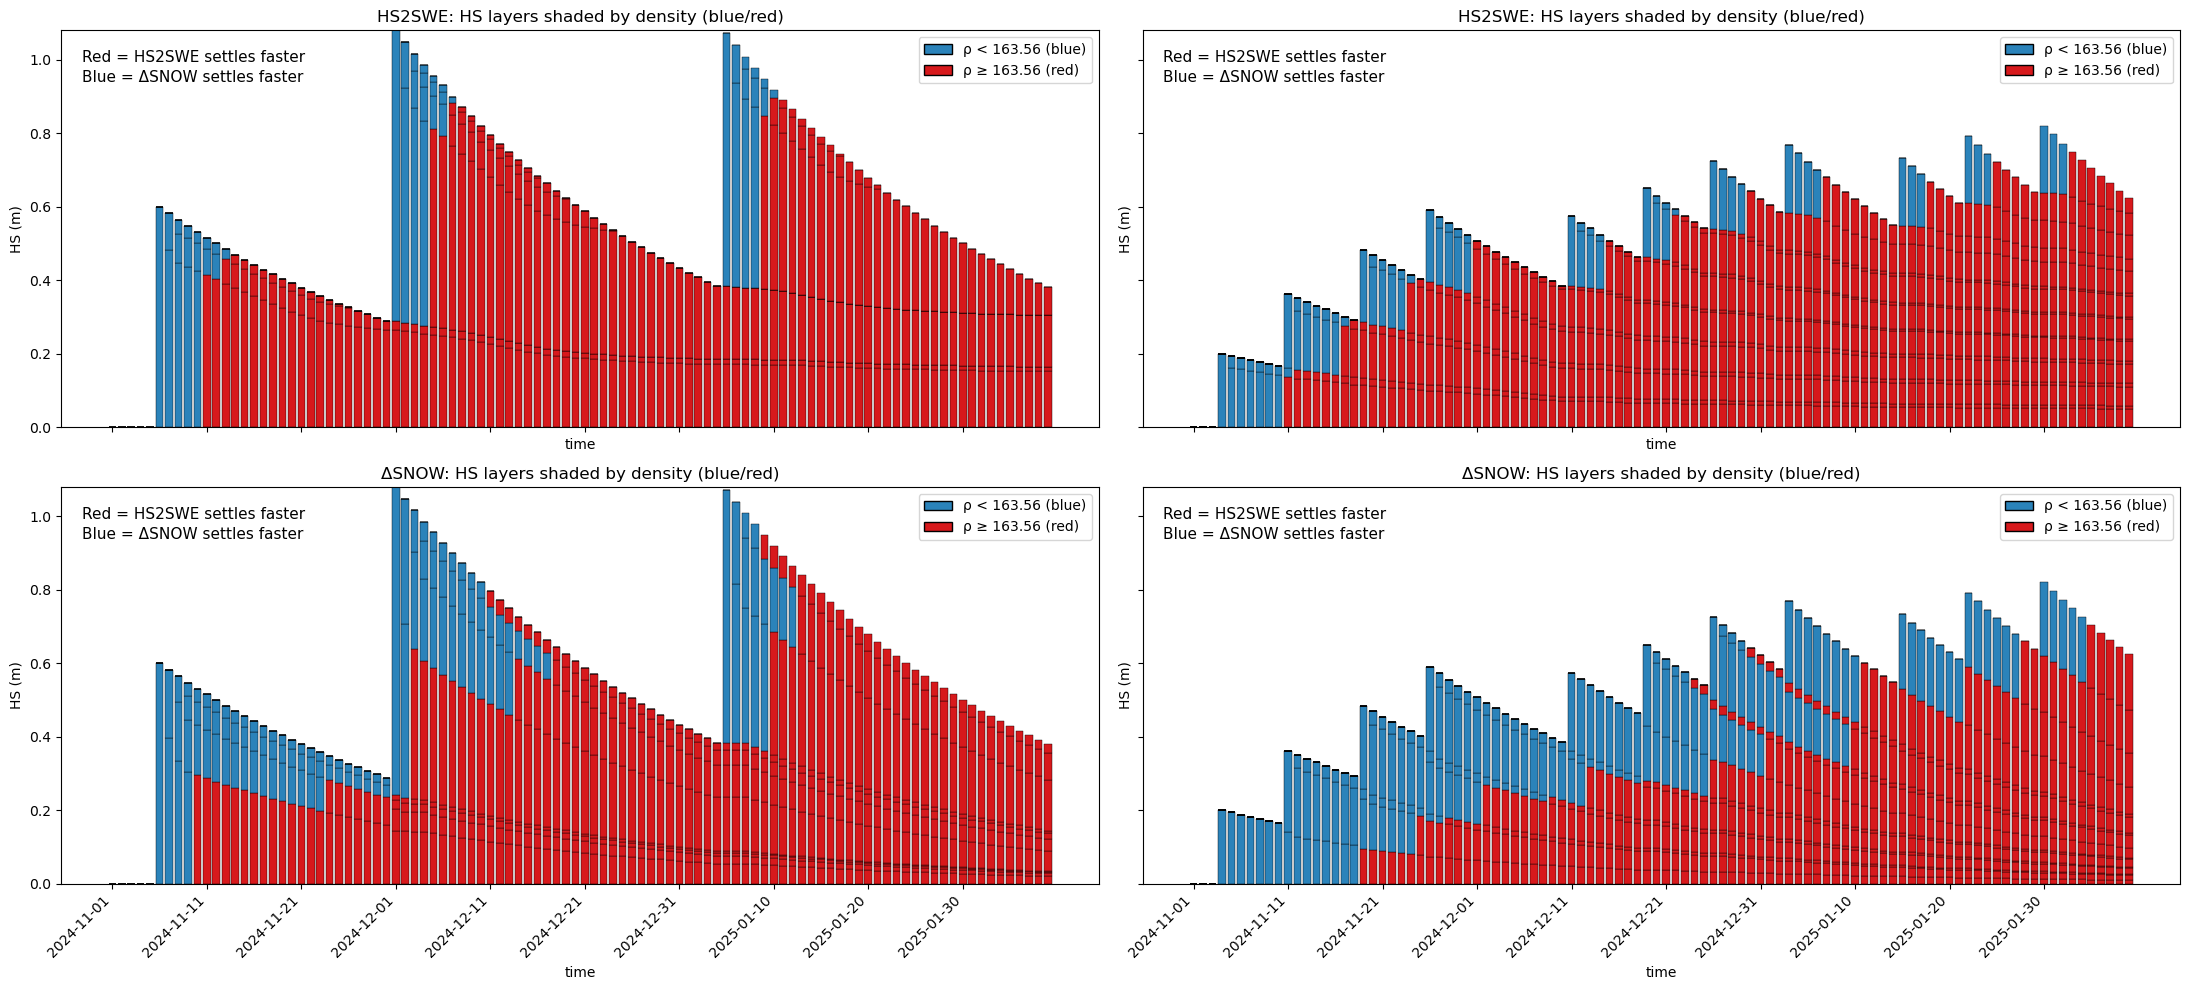

In [10]:
# ============================================================
# HS stacked bars shaded by binary density (blue/red)
# BIG (left) vs SMALL (right), each column has 2 rows:
#   row 1: HS2SWE
#   row 2: ΔSNOW
# ============================================================

from matplotlib.patches import Patch

def plot_hs_stacked_binary_rho_ax(ax, ds, model_name, time_labels,
                                 center=163.56,
                                 low_color="#2b83ba",
                                 high_color="#d7191c"):
    HS = as_time_layer(ds["HS"]).astype(float)
    RHO = as_time_layer(ds["RHO"]).astype(float)

    T, L = HS.shape
    x = np.arange(T)
    bottom = np.zeros(T)

    HS = np.where(np.isfinite(HS), HS, 0.0)

    for j in range(L):
        hj = HS[:, j]
        if np.allclose(hj, 0.0):
            continue

        rho_j = RHO[:, j]
        colors = np.where(rho_j < center, low_color, high_color)
        colors = np.where(np.isfinite(rho_j), colors, "#cccccc")

        ax.bar(
            x, hj, bottom=bottom,
            color=colors,
            edgecolor="black",
            linewidth=0.3
        )
        bottom += hj

    ax.set_title(f"{model_name}: HS layers shaded by density (blue/red)")
    ax.set_xlabel("time")
    ax.set_ylabel("HS (m)")

    step = max(1, int(len(time_labels) / 10))
    ticks = np.arange(0, len(time_labels), step)
    ax.set_xticks(ticks)
    ax.set_xticklabels(time_labels[ticks], rotation=45, ha="right")

    legend_elements = [
        Patch(facecolor=low_color, edgecolor="black", label=f"ρ < {center:.2f} (blue)"),
        Patch(facecolor=high_color, edgecolor="black", label=f"ρ ≥ {center:.2f} (red)")
    ]
    ax.legend(handles=legend_elements, loc="upper right")

    ax.text(0.02, 0.95, "Red = HS2SWE settles faster",
            transform=ax.transAxes, fontsize=11, verticalalignment="top")
    ax.text(0.02, 0.90, "Blue = ΔSNOW settles faster",
            transform=ax.transAxes, fontsize=11, verticalalignment="top")


# -----------------------------
# Side-by-side BIG vs SMALL
# Requires: cases["big"], cases["small"]
# Each case contains: ds_hs2swe, ds_dsnow, time_labels (or get_time_labels)
# -----------------------------
center = 163.56
low_color = "#2b83ba"
high_color = "#d7191c"

col_titles = {"big": "BIG snowfall", "small": "SMALL snowfall"}

fig, axes = plt.subplots(2, 2, figsize=(22, 10), sharex="col", sharey="row")

for c, k in enumerate(["big", "small"]):
    ds_hs2swe = cases[k]["ds_hs2swe"]
    ds_dsnow  = cases[k]["ds_dsnow"]
    time_labels = cases[k].get("time_labels", get_time_labels(ds_dsnow))

    axes[0, c].set_title(f"{col_titles[k]} | HS2SWE")
    plot_hs_stacked_binary_rho_ax(
        axes[0, c], ds_hs2swe, "HS2SWE", time_labels,
        center=center, low_color=low_color, high_color=high_color
    )

    axes[1, c].set_title(f"{col_titles[k]} | ΔSNOW")
    plot_hs_stacked_binary_rho_ax(
        axes[1, c], ds_dsnow, "ΔSNOW", time_labels,
        center=center, low_color=low_color, high_color=high_color
    )

plt.tight_layout()
plt.show()

## 7) Lowest layers diagnostics (BIG vs SMALL side-by-side)
This reproduces your three-panel plot (HS, mean density, SWE) but with **two columns** (big left, small right).

/var/folders/r5/2d5m4_zn37d74npwnbfcpcdh0000gn/T/ipykernel_3163/1733255588.py:12: RuntimeWarning: Mean of empty slice
  rho_low_ds = np.nanmean(as_time_layer(ds_dsnow_low["RHO"]), axis=1)



Case BIG:
  ΔSNOW selected layers: [1 2 3]
  HS2SWE selected layers: [1 2 3 4]

Case SMALL:
  ΔSNOW selected layers: [1 2 3]
  HS2SWE selected layers: [1 2 3 4]


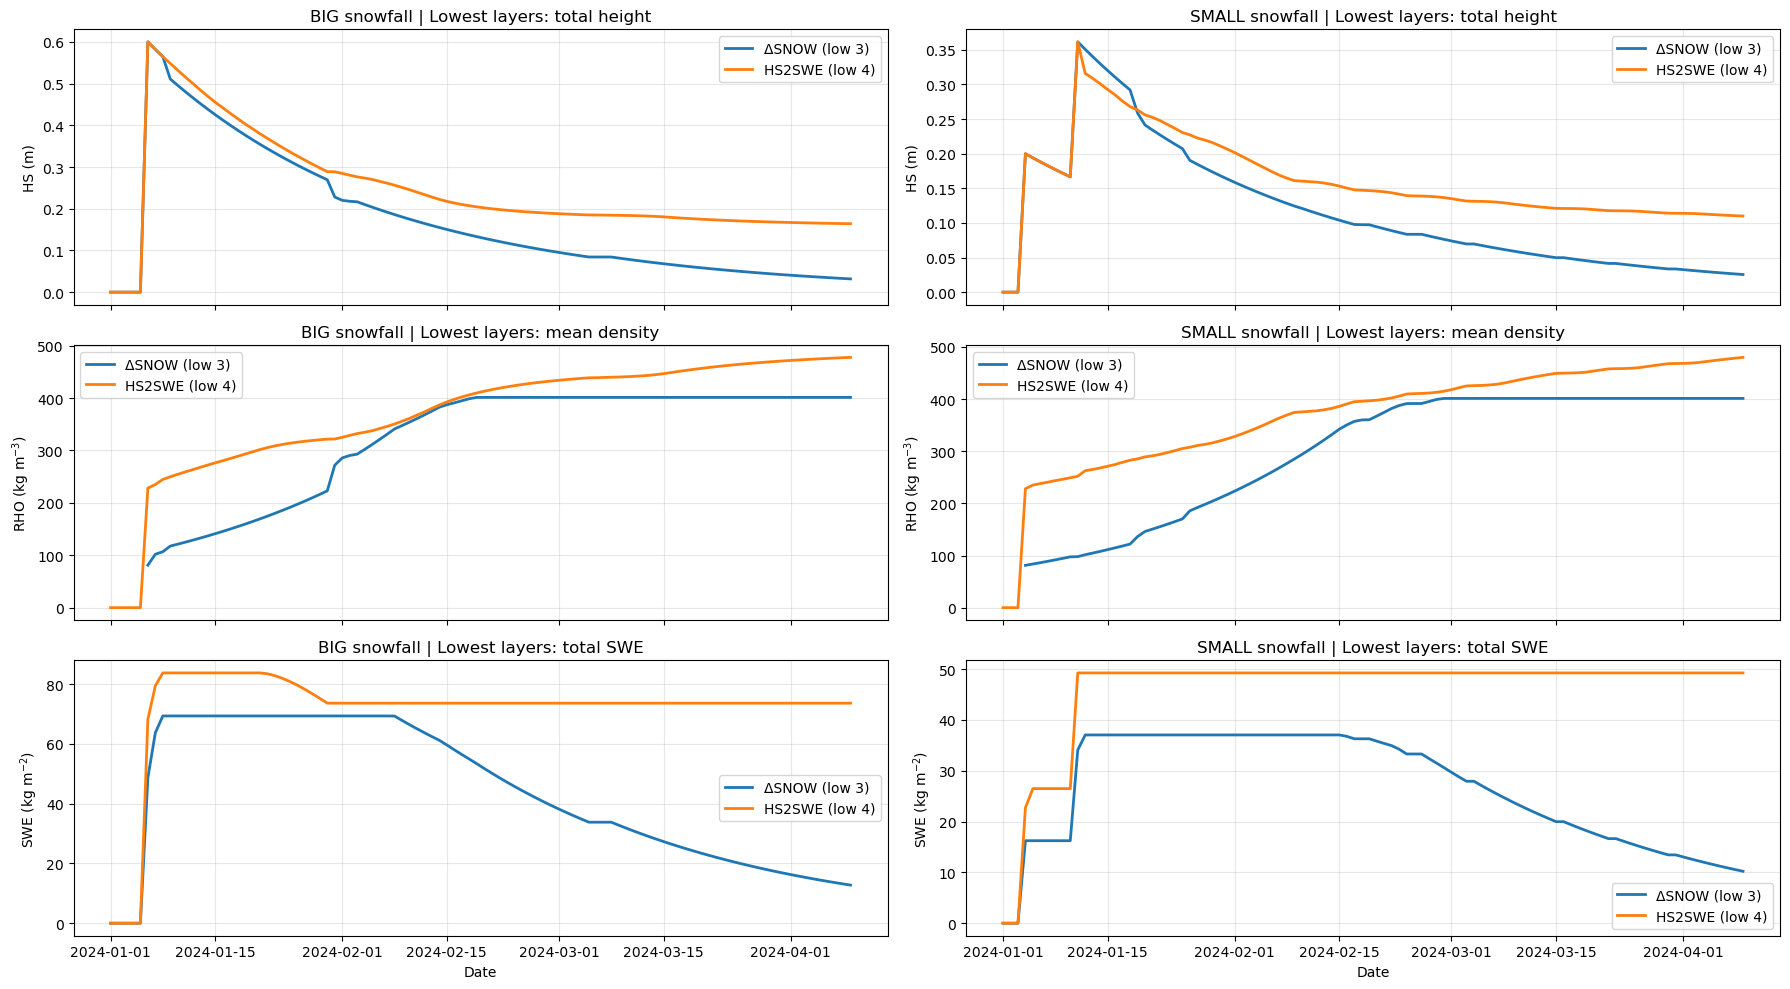

In [11]:
# USER SETTINGS
lowest_n_ds = 3   # ΔSNOW: number of lowest layers
lowest_n_hs = 4   # HS2SWE: number of lowest layers

def build_low_layer_series(ds_dsnow, ds_hs2swe, lowest_n_ds, lowest_n_hs):
    ds_dsnow_low  = ds_dsnow.isel(layer=slice(0, lowest_n_ds))
    ds_hs2swe_low = ds_hs2swe.isel(layer=slice(0, lowest_n_hs))

    hs_low_ds = np.nansum(as_time_layer(ds_dsnow_low["HS"]), axis=1)
    hs_low_hs = np.nansum(as_time_layer(ds_hs2swe_low["HS"]), axis=1)

    rho_low_ds = np.nanmean(as_time_layer(ds_dsnow_low["RHO"]), axis=1)
    rho_low_hs = np.nanmean(as_time_layer(ds_hs2swe_low["RHO"]), axis=1)

    swe_low_ds = np.nansum(as_time_layer(ds_dsnow_low["swe"]), axis=1)
    swe_low_hs = np.nansum(as_time_layer(ds_hs2swe_low["swe"]), axis=1)

    return dict(
        ds_layers=ds_dsnow_low["layer"].values,
        hs_layers=ds_hs2swe_low["layer"].values,
        hs_low_ds=hs_low_ds, hs_low_hs=hs_low_hs,
        rho_low_ds=rho_low_ds, rho_low_hs=rho_low_hs,
        swe_low_ds=swe_low_ds, swe_low_hs=swe_low_hs
    )

# Build per case
low = {}
for k in ["big", "small"]:
    ds_dsnow  = cases[k]["ds_dsnow"]
    ds_hs2swe = cases[k]["ds_hs2swe"]
    low[k] = build_low_layer_series(ds_dsnow, ds_hs2swe, lowest_n_ds, lowest_n_hs)
    print(f"\nCase {k.upper()}:")
    print("  ΔSNOW selected layers:", low[k]["ds_layers"])
    print("  HS2SWE selected layers:", low[k]["hs_layers"])

# Plot (3 rows x 2 cols)
fig, axes = plt.subplots(3, 2, figsize=(18, 10), sharex="col")
for c, k in enumerate(["big", "small"]):
    time_axis = cases[k]["time_axis"]
    n = cases[k]["n"]
    snowpack = cases[k]["snowpack"]
    have_obs = (snowpack is not None)

    if have_obs:
        hs_obs = np.asarray(snowpack["HS_meas"].values, dtype=float)
        swe_obs = np.asarray(snowpack["SWE"].values, dtype=float)
        n_plot = min(
            n, len(hs_obs), len(swe_obs),
            len(low[k]["hs_low_ds"]), len(low[k]["hs_low_hs"]),
            len(low[k]["rho_low_ds"]), len(low[k]["rho_low_hs"]),
            len(low[k]["swe_low_ds"]), len(low[k]["swe_low_hs"])
        )
    else:
        n_plot = min(
            n,
            len(low[k]["hs_low_ds"]), len(low[k]["hs_low_hs"]),
            len(low[k]["rho_low_ds"]), len(low[k]["rho_low_hs"]),
            len(low[k]["swe_low_ds"]), len(low[k]["swe_low_hs"])
        )

    # HS panel
    ax = axes[0, c]
    if have_obs:
        ax.fill_between(time_axis[:n_plot], 0, hs_obs[:n_plot],
                        color="lightgray", alpha=0.45, label="SNOWPACK HS")
    ax.plot(time_axis[:n_plot], low[k]["hs_low_ds"][:n_plot],
            label=f"ΔSNOW (low {lowest_n_ds})", linewidth=2)
    ax.plot(time_axis[:n_plot], low[k]["hs_low_hs"][:n_plot],
            label=f"HS2SWE (low {lowest_n_hs})", linewidth=2)
    ax.set_ylabel("HS (m)")
    ax.set_title(f"{col_titles[k]} | Lowest layers: total height")
    ax.grid(True, alpha=0.3)
    ax.legend()

    # Density panel
    ax = axes[1, c]
    ax.plot(time_axis[:n_plot], low[k]["rho_low_ds"][:n_plot],
            label=f"ΔSNOW (low {lowest_n_ds})", linewidth=2)
    ax.plot(time_axis[:n_plot], low[k]["rho_low_hs"][:n_plot],
            label=f"HS2SWE (low {lowest_n_hs})", linewidth=2)
    ax.set_ylabel("RHO (kg m$^{-3}$)")
    ax.set_title(f"{col_titles[k]} | Lowest layers: mean density")
    ax.grid(True, alpha=0.3)
    ax.legend()

    # SWE panel
    ax = axes[2, c]
    if have_obs:
        ax.fill_between(time_axis[:n_plot], 0, swe_obs[:n_plot],
                        color="lightgray", alpha=0.45, label="SNOWPACK SWE")
    ax.plot(time_axis[:n_plot], low[k]["swe_low_ds"][:n_plot],
            label=f"ΔSNOW (low {lowest_n_ds})", linewidth=2)
    ax.plot(time_axis[:n_plot], low[k]["swe_low_hs"][:n_plot],
            label=f"HS2SWE (low {lowest_n_hs})", linewidth=2)
    ax.set_ylabel("SWE (kg m$^{-2}$)")
    ax.set_title(f"{col_titles[k]} | Lowest layers: total SWE")
    ax.grid(True, alpha=0.3)
    ax.legend()
    ax.set_xlabel("Date")

plt.tight_layout()
plt.show()


## 8) Common active HS layers (sum from first non-zero time in both models)
Produces two plots side-by-side: raw summed HS and cumulative summed HS.

BIG: Common layers used: 10 / 11
SMALL: Common layers used: 15 / 16


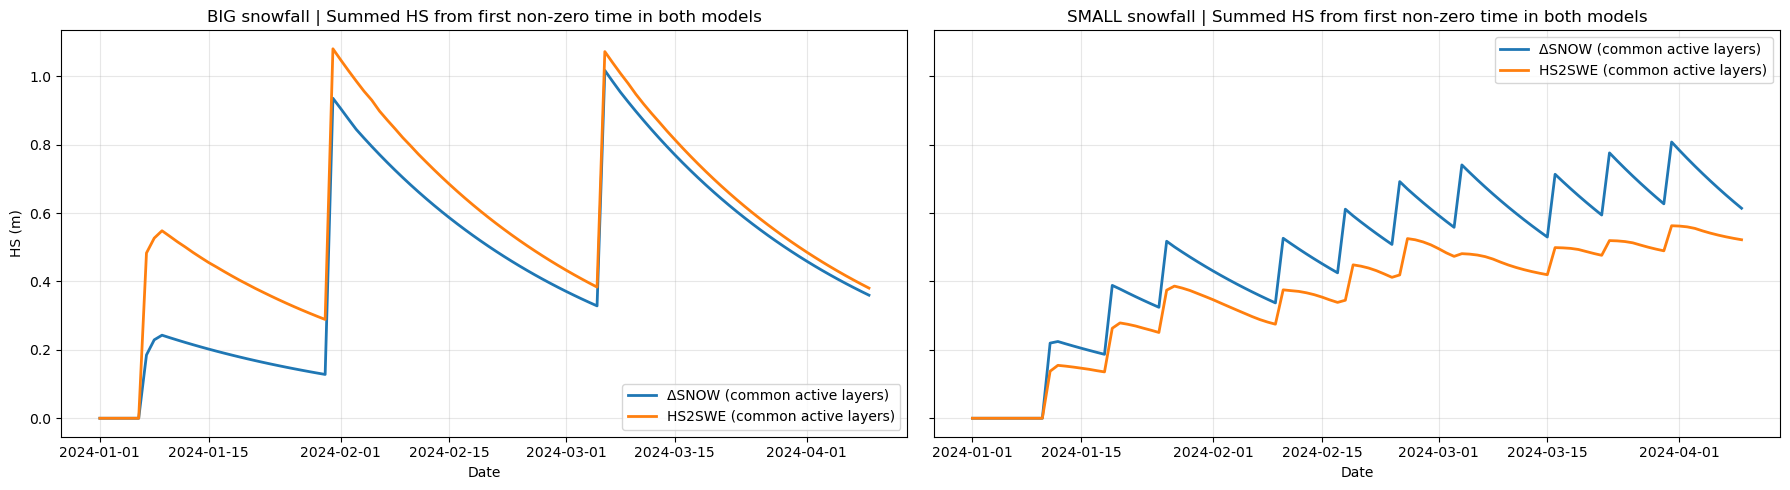

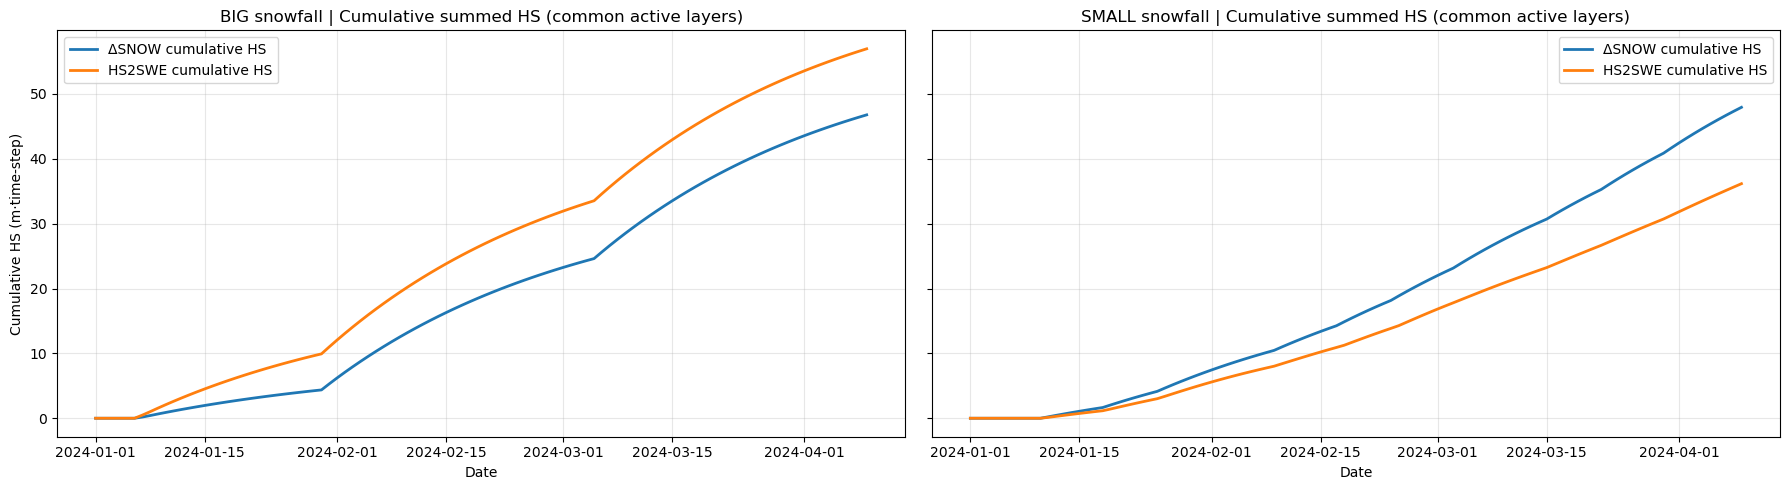

In [12]:
def common_active_hs(ds_dsnow, ds_hs2swe, time_axis):
    HS_ds = as_time_layer(ds_dsnow["HS"]).astype(float)
    HS_hs = as_time_layer(ds_hs2swe["HS"]).astype(float)

    T = min(HS_ds.shape[0], HS_hs.shape[0], len(time_axis))
    L = min(HS_ds.shape[1], HS_hs.shape[1])

    HS_ds = HS_ds[:T, :L]
    HS_hs = HS_hs[:T, :L]

    first_ds = np.array([first_nonzero_idx(HS_ds[:, j]) for j in range(L)], dtype=float)
    first_hs = np.array([first_nonzero_idx(HS_hs[:, j]) for j in range(L)], dtype=float)

    common_layers = np.isfinite(first_ds) & np.isfinite(first_hs)
    start_idx = np.maximum(first_ds, first_hs)  # first time both have non-zero HS for that layer

    t_idx = np.arange(T)[:, None]
    active_mask = common_layers[None, :] & (t_idx >= start_idx[None, :])

    hs_sum_ds_common = np.nansum(np.where(active_mask, HS_ds, 0.0), axis=1)
    hs_sum_hs_common = np.nansum(np.where(active_mask, HS_hs, 0.0), axis=1)

    hs_cum_ds_common = np.cumsum(np.nan_to_num(hs_sum_ds_common, nan=0.0))
    hs_cum_hs_common = np.cumsum(np.nan_to_num(hs_sum_hs_common, nan=0.0))

    return dict(
        T=T, L=L,
        common_layers=common_layers,
        hs_sum_ds=hs_sum_ds_common,
        hs_sum_hs=hs_sum_hs_common,
        hs_cum_ds=hs_cum_ds_common,
        hs_cum_hs=hs_cum_hs_common
    )

# compute per case
hs_common = {}
for k in ["big", "small"]:
    hs_common[k] = common_active_hs(cases[k]["ds_dsnow"], cases[k]["ds_hs2swe"], cases[k]["time_axis"])
    print(f"{k.upper()}: Common layers used: {int(hs_common[k]['common_layers'].sum())} / {hs_common[k]['L']}")

# plot summed HS (1x2)
fig, axes = plt.subplots(1, 2, figsize=(18, 5), sharey=True)
for ax, k in zip(axes, ["big", "small"]):
    T = hs_common[k]["T"]
    time_axis = cases[k]["time_axis"]

    ax.plot(time_axis[:T], hs_common[k]["hs_sum_ds"], label="ΔSNOW (common active layers)", linewidth=2)
    ax.plot(time_axis[:T], hs_common[k]["hs_sum_hs"], label="HS2SWE (common active layers)", linewidth=2)
    ax.set_title(f"{col_titles[k]} | Summed HS from first non-zero time in both models")
    ax.set_xlabel("Date")
    ax.grid(True, alpha=0.3)
    ax.legend()
axes[0].set_ylabel("HS (m)")
plt.tight_layout()
plt.show()

# plot cumulative summed HS (1x2)
fig, axes = plt.subplots(1, 2, figsize=(18, 5), sharey=True)
for ax, k in zip(axes, ["big", "small"]):
    T = hs_common[k]["T"]
    time_axis = cases[k]["time_axis"]

    ax.plot(time_axis[:T], hs_common[k]["hs_cum_ds"], label="ΔSNOW cumulative HS", linewidth=2)
    ax.plot(time_axis[:T], hs_common[k]["hs_cum_hs"], label="HS2SWE cumulative HS", linewidth=2)
    ax.set_title(f"{col_titles[k]} | Cumulative summed HS (common active layers)")
    ax.set_xlabel("Date")
    ax.grid(True, alpha=0.3)
    ax.legend()
axes[0].set_ylabel("Cumulative HS (m·time-step)")
plt.tight_layout()
plt.show()


## 9) Common active SWE layers and decrease metrics (3 rows x 2 cols)
For each case (column):
1) total SWE from common active layers
2) SWE decreases only (positive magnitudes)
3) cumulative SWE decrease

BIG: Common SWE layers used: 10 / 11
         SNOWPACK used: False
SMALL: Common SWE layers used: 15 / 16
         SNOWPACK used: False


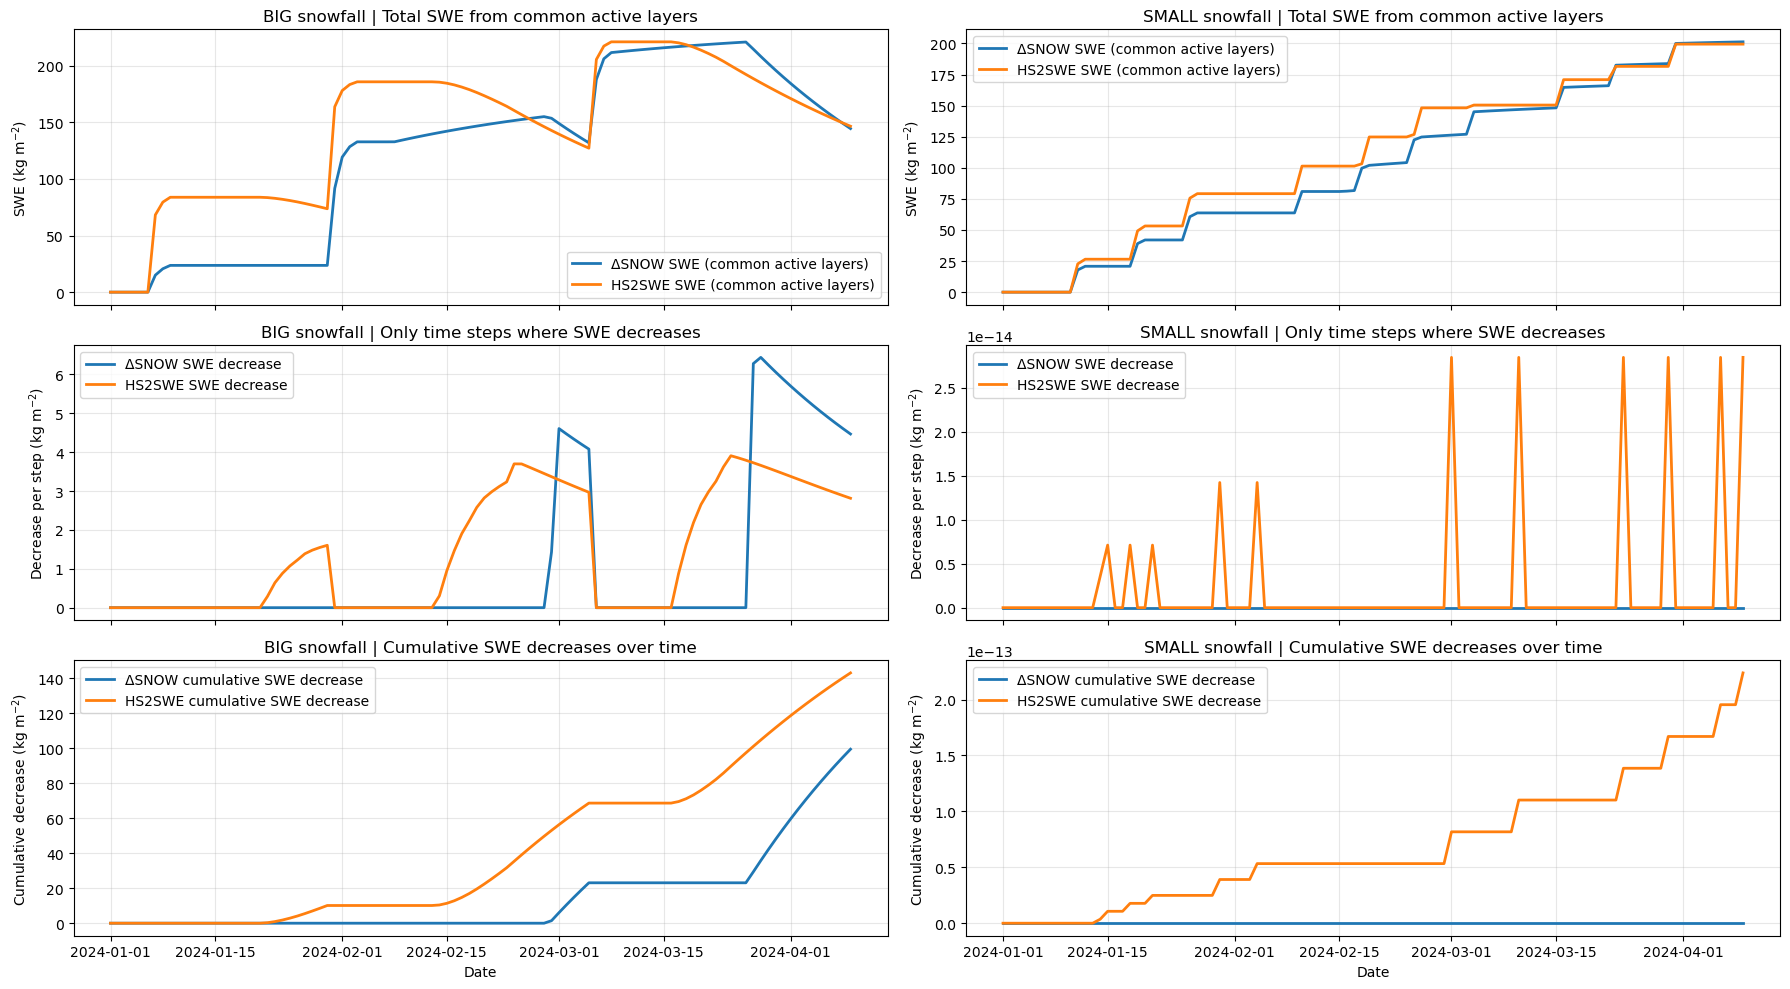

In [13]:
def common_active_swe_and_decrease(ds_dsnow, ds_hs2swe, time_axis, snowpack=None):
    SWE_ds = as_time_layer(ds_dsnow["swe"]).astype(float)
    SWE_hs = as_time_layer(ds_hs2swe["swe"]).astype(float)

    T = min(SWE_ds.shape[0], SWE_hs.shape[0], len(time_axis))
    L = min(SWE_ds.shape[1], SWE_hs.shape[1])

    SWE_ds = SWE_ds[:T, :L]
    SWE_hs = SWE_hs[:T, :L]

    first_ds_swe = np.array([first_nonzero_idx(SWE_ds[:, j]) for j in range(L)], dtype=float)
    first_hs_swe = np.array([first_nonzero_idx(SWE_hs[:, j]) for j in range(L)], dtype=float)

    common_layers_swe = np.isfinite(first_ds_swe) & np.isfinite(first_hs_swe)
    start_idx_swe = np.maximum(first_ds_swe, first_hs_swe)

    t_idx = np.arange(T)[:, None]
    active_mask_swe = common_layers_swe[None, :] & (t_idx >= start_idx_swe[None, :])

    swe_sum_ds_common = np.nansum(np.where(active_mask_swe, SWE_ds, 0.0), axis=1)
    swe_sum_hs_common = np.nansum(np.where(active_mask_swe, SWE_hs, 0.0), axis=1)

    ds_delta = np.diff(swe_sum_ds_common, prepend=np.nan)
    hs_delta = np.diff(swe_sum_hs_common, prepend=np.nan)

    ds_decrease = np.where(ds_delta < 0, -ds_delta, 0.0)
    hs_decrease = np.where(hs_delta < 0, -hs_delta, 0.0)

    ds_cum_decrease = np.nancumsum(ds_decrease)
    hs_cum_decrease = np.nancumsum(hs_decrease)

    have_obs = (snowpack is not None)
    if have_obs:
        swe_obs = np.asarray(snowpack["SWE"].values, dtype=float)
        T_obs = min(T, len(swe_obs))
        swe_obs_T = swe_obs[:T_obs]

        obs_delta = np.diff(swe_obs_T, prepend=np.nan)
        obs_decrease = np.where(obs_delta < 0, -obs_delta, 0.0)
        obs_cum_decrease = np.nancumsum(obs_decrease)
    else:
        T_obs = T
        swe_obs_T = None
        obs_decrease = None
        obs_cum_decrease = None

    return dict(
        T=T, L=L,
        common_layers_swe=common_layers_swe,
        swe_sum_ds=swe_sum_ds_common,
        swe_sum_hs=swe_sum_hs_common,
        ds_decrease=ds_decrease,
        hs_decrease=hs_decrease,
        ds_cum_decrease=ds_cum_decrease,
        hs_cum_decrease=hs_cum_decrease,
        have_obs=have_obs,
        T_obs=T_obs,
        swe_obs_T=swe_obs_T,
        obs_decrease=obs_decrease,
        obs_cum_decrease=obs_cum_decrease
    )

swe_common = {}
for k in ["big", "small"]:
    swe_common[k] = common_active_swe_and_decrease(
        cases[k]["ds_dsnow"], cases[k]["ds_hs2swe"], cases[k]["time_axis"], cases[k]["snowpack"]
    )
    print(f"{k.upper()}: Common SWE layers used: {int(swe_common[k]['common_layers_swe'].sum())} / {swe_common[k]['L']}")
    print(f"         SNOWPACK used: {swe_common[k]['have_obs']}")

fig, axes = plt.subplots(3, 2, figsize=(18, 10), sharex="col")

for c, k in enumerate(["big", "small"]):
    time_axis = cases[k]["time_axis"]
    T = swe_common[k]["T"]
    have_obs = swe_common[k]["have_obs"]

    # 1) total SWE
    ax = axes[0, c]
    ax.plot(time_axis[:T], swe_common[k]["swe_sum_ds"], label="ΔSNOW SWE (common active layers)", linewidth=2)
    ax.plot(time_axis[:T], swe_common[k]["swe_sum_hs"], label="HS2SWE SWE (common active layers)", linewidth=2)
    if have_obs:
        T_obs = swe_common[k]["T_obs"]
        ax.plot(time_axis[:T_obs], swe_common[k]["swe_obs_T"], label="SNOWPACK SWE", linestyle="--", linewidth=1.8)
    ax.set_ylabel("SWE (kg m$^{-2}$)")
    ax.set_title(f"{col_titles[k]} | Total SWE from common active layers")
    ax.grid(True, alpha=0.3)
    ax.legend()

    # 2) SWE decreases only
    ax = axes[1, c]
    ax.plot(time_axis[:T], swe_common[k]["ds_decrease"], label="ΔSNOW SWE decrease", linewidth=2)
    ax.plot(time_axis[:T], swe_common[k]["hs_decrease"], label="HS2SWE SWE decrease", linewidth=2)
    if have_obs:
        T_obs = swe_common[k]["T_obs"]
        ax.plot(time_axis[:T_obs], swe_common[k]["obs_decrease"], label="SNOWPACK SWE decrease", linestyle="--", linewidth=1.8)
    ax.set_ylabel("Decrease per step (kg m$^{-2}$)")
    ax.set_title(f"{col_titles[k]} | Only time steps where SWE decreases")
    ax.grid(True, alpha=0.3)
    ax.legend()

    # 3) cumulative decreases
    ax = axes[2, c]
    ax.plot(time_axis[:T], swe_common[k]["ds_cum_decrease"], label="ΔSNOW cumulative SWE decrease", linewidth=2)
    ax.plot(time_axis[:T], swe_common[k]["hs_cum_decrease"], label="HS2SWE cumulative SWE decrease", linewidth=2)
    if have_obs:
        T_obs = swe_common[k]["T_obs"]
        ax.plot(time_axis[:T_obs], swe_common[k]["obs_cum_decrease"], label="SNOWPACK cumulative SWE decrease", linestyle="--", linewidth=1.8)
    ax.set_ylabel("Cumulative decrease (kg m$^{-2}$)")
    ax.set_title(f"{col_titles[k]} | Cumulative SWE decreases over time")
    ax.set_xlabel("Date")
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

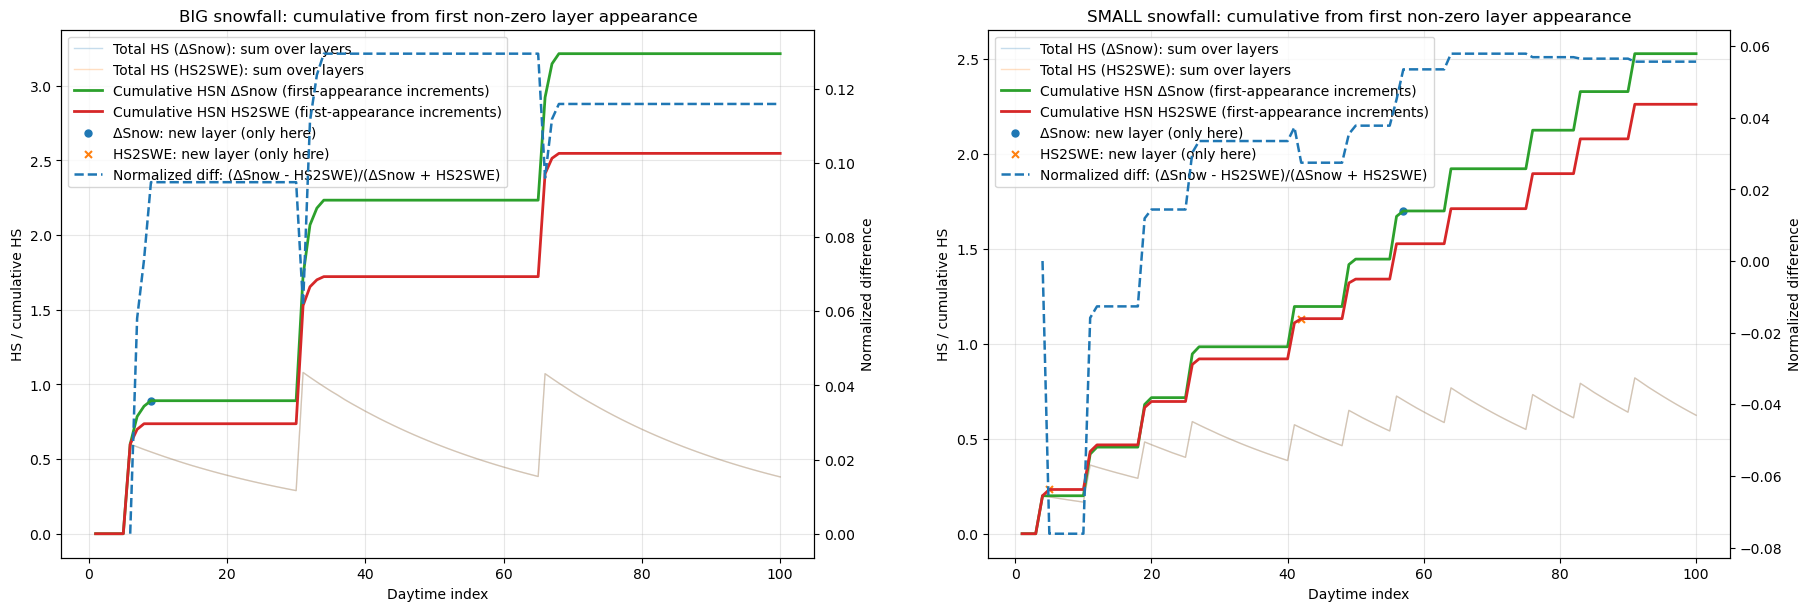

In [19]:
def plot_case(ax, ds_dsnow, ds_hs2swe, title, xlabel="Daytime index", eps=1e-12):
    # ---------- TOTAL HS (background) ----------
    hs_total_dsnow = ds_dsnow["HS"].where(np.isfinite(ds_dsnow["HS"]), 0.0).sum("layer").to_pandas()
    hs_total_hs2swe = ds_hs2swe["HS"].where(np.isfinite(ds_hs2swe["HS"]), 0.0).sum("layer").to_pandas()

    # Background lines (total HS)
    ax.plot(hs_total_dsnow.index, hs_total_dsnow.values, linewidth=1.0, alpha=0.25,
            label="Total HS (ΔSnow): sum over layers")
    ax.plot(hs_total_hs2swe.index, hs_total_hs2swe.values, linewidth=1.0, alpha=0.25,
            label="Total HS (HS2SWE): sum over layers")

    # ---------- your existing cumulative-from-first-appearance logic ----------
    hs_da = ds_dsnow["HS"]
    hs_first_vals, hs_first_times = first_nonzero_by_layer(hs_da)
    time_axis = ds_dsnow["time"].values
    hs_df, hs_event_times, _ = increments_and_cumsum(hs_first_vals, hs_first_times, time_axis)

    hs2_da = ds_hs2swe["HS"]
    hs2_first_vals, hs2_first_times = first_nonzero_by_layer(hs2_da)
    time_axis2 = ds_hs2swe["time"].values
    hs2_df, hs2_event_times, _ = increments_and_cumsum(hs2_first_vals, hs2_first_times, time_axis2)

    # Align for normalized diff
    common_index = hs_df.index.union(hs2_df.index)
    c1 = hs_df.reindex(common_index)["cumulative"].astype(float).interpolate(limit_direction="both")
    c2 = hs2_df.reindex(common_index)["cumulative"].astype(float).interpolate(limit_direction="both")

    denom = (c1 + c2).to_numpy()
    nd = (c1.to_numpy() - c2.to_numpy()) / np.where(np.abs(denom) < eps, np.nan, denom)
    nd_s = pd.Series(nd, index=common_index)

    # XOR event times
    hs_t  = pd.Index(hs_event_times)
    hs2_t = pd.Index(hs2_event_times)
    hs_only_times  = hs_t.difference(hs2_t)
    hs2_only_times = hs2_t.difference(hs_t)

    hs_only_y  = hs_df.loc[hs_only_times,  "cumulative"].to_numpy()
    hs2_only_y = hs2_df.loc[hs2_only_times, "cumulative"].to_numpy()

    # Cumulative curves
    ax.plot(hs_df.index, hs_df["cumulative"], linewidth=2,
            label="Cumulative HSN ΔSnow (first-appearance increments)")
    ax.plot(hs2_df.index, hs2_df["cumulative"], linewidth=2,
            label="Cumulative HSN HS2SWE (first-appearance increments)")

    # XOR markers
    ax.scatter(hs_only_times, hs_only_y, s=25, marker="o",
               label="ΔSnow: new layer (only here)")
    ax.scatter(hs2_only_times, hs2_only_y, s=25, marker="x",
               label="HS2SWE: new layer (only here)")

    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("HS / cumulative HS")
    ax.grid(True, alpha=0.3)

    # Normalized difference on twin axis
    ax2 = ax.twinx()
    ax2.plot(nd_s.index, nd_s.values, linestyle="--", linewidth=1.8,
             label="Normalized diff: (ΔSnow - HS2SWE)/(ΔSnow + HS2SWE)")
    ax2.set_ylabel("Normalized difference")

    # Combined legend
    h1, l1 = ax.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    ax.legend(h1 + h2, l1 + l2, loc="best")

# ============================================================
# Two subfigures: BIG (left) and SMALL (right)
# cases["big"] and cases["small"] must contain ds_dsnow and ds_hs2swe
# ============================================================
fig = plt.figure(figsize=(18, 6), constrained_layout=True)
subfigs = fig.subfigures(1, 2, wspace=0.06)

for sf, key in zip(subfigs, ["big", "small"]):
    ax = sf.subplots(1, 1)

    ds_dsnow = cases[key]["ds_dsnow"]
    ds_hs2swe = cases[key]["ds_hs2swe"]

    plot_case(
        ax=ax,
        ds_dsnow=ds_dsnow,
        ds_hs2swe=ds_hs2swe,
        title=f"{key.upper()} snowfall: cumulative from first non-zero layer appearance"
    )

plt.show()


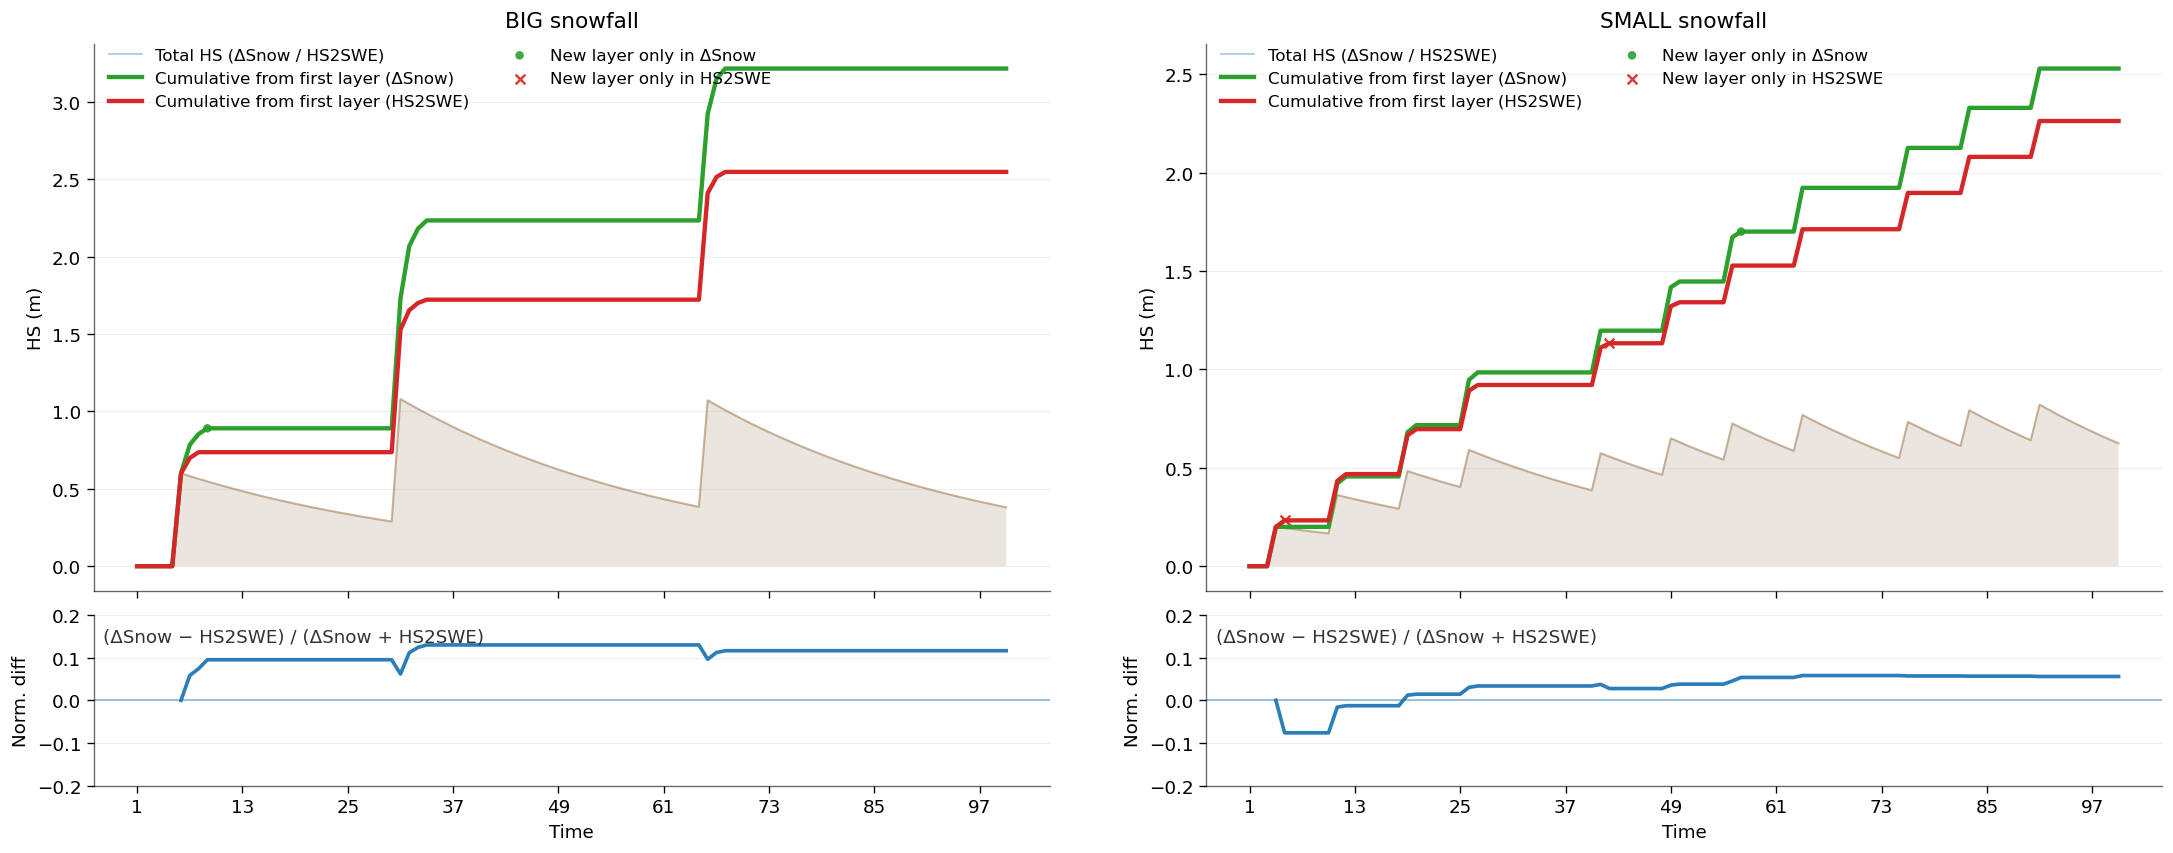

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr
import matplotlib as mpl

# ----------------------------
# Global "modern" style
# ----------------------------
mpl.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "legend.fontsize": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": False,
    "xtick.direction": "out",
    "ytick.direction": "out",
})

def _beautify_axes(ax):
    ax.set_facecolor("white")
    ax.spines["left"].set_alpha(0.6)
    ax.spines["bottom"].set_alpha(0.6)
    ax.tick_params(axis="both", which="major", length=4, width=0.8)
    ax.grid(axis="y", alpha=0.18, linewidth=0.8)

def _nice_xticks(ax, x, max_ticks=8):
    # reduce tick clutter for long series
    n = len(x)
    if n <= max_ticks:
        return
    step = max(1, n // max_ticks)
    ticks = np.arange(0, n, step)
    ax.set_xticks(x[ticks])
    # rotate only if labels are non-numeric / datetime-like
    if not np.issubdtype(np.asarray(x).dtype, np.number):
        ax.tick_params(axis="x", labelrotation=35)
        for lab in ax.get_xticklabels():
            lab.set_ha("right")

# ----------------------------
# Your existing helpers (unchanged)
# ----------------------------
def first_nonzero_by_layer(da: xr.DataArray, time_dim="time", layer_dim="layer"):
    valid = np.isfinite(da) & (da != 0)
    first_idx = valid.argmax(dim=time_dim)
    valid_layers = valid.any(dim=time_dim)
    first_values = da.isel({time_dim: first_idx}).where(valid_layers, drop=True)
    first_times  = da[time_dim].isel({time_dim: first_idx}).where(valid_layers, drop=True)
    return first_values, first_times

def increments_and_cumsum(first_values: xr.DataArray,
                          first_times: xr.DataArray,
                          time_axis,
                          time_is_1_to_N: bool | None = None):
    inc = np.zeros(len(time_axis), dtype=float)

    vals = np.asarray(first_values.values, dtype=float)
    tvals = first_times.values

    if time_is_1_to_N is None:
        time_is_1_to_N = np.issubdtype(np.asarray(tvals).dtype, np.number)

    if time_is_1_to_N:
        pos = np.asarray(tvals, dtype=float).astype(int) - 1
    else:
        idx = pd.Index(pd.to_datetime(time_axis))
        t_dt = pd.to_datetime(tvals)
        pos = idx.get_indexer(t_dt)

    m = np.isfinite(vals) & np.isfinite(pos) & (pos >= 0) & (pos < len(time_axis))
    pos_m = pos[m].astype(int)

    np.add.at(inc, pos_m, vals[m])

    df = pd.DataFrame({"increment": inc}, index=time_axis)
    df["cumulative"] = df["increment"].cumsum()

    event_pos = np.unique(pos_m)
    event_times = df.index[event_pos]
    event_y = df["cumulative"].to_numpy()[event_pos]

    return df, event_times, event_y

# ----------------------------
# Nicer plotting
# ----------------------------
def plot_case(ax_main, ax_nd, ds_dsnow, ds_hs2swe, title, xlabel="Daytime index", eps=1e-12):
    _beautify_axes(ax_main)
    _beautify_axes(ax_nd)

    # Colors (let Matplotlib choose defaults, but keep consistent roles)
    c_dsnow  = None  # default cycle color 0
    c_hs2swe = None  # default cycle color 1

    # ---------- TOTAL HS as soft background band ----------
    hs_total_dsnow  = ds_dsnow["HS"].where(np.isfinite(ds_dsnow["HS"]), 0.0).sum("layer").to_pandas()
    hs_total_hs2swe = ds_hs2swe["HS"].where(np.isfinite(ds_hs2swe["HS"]), 0.0).sum("layer").to_pandas()

    # align totals to common index for clean fill
    total_index = hs_total_dsnow.index.union(hs_total_hs2swe.index)
    t_ds = hs_total_dsnow.reindex(total_index).astype(float).interpolate(limit_direction="both")
    t_h2 = hs_total_hs2swe.reindex(total_index).astype(float).interpolate(limit_direction="both")

    # Fill bands (subtle)
    ax_main.fill_between(total_index, 0.0, t_ds.values, alpha=0.10, linewidth=0)
    ax_main.fill_between(total_index, 0.0, t_h2.values, alpha=0.10, linewidth=0)

    # Light outlines for totals
    ax_main.plot(total_index, t_ds.values, linewidth=1.2, alpha=0.35, label="Total HS (ΔSnow / HS2SWE)")
    ax_main.plot(total_index, t_h2.values, linewidth=1.2, alpha=0.35)

    # ---------- cumulative-from-first-appearance ----------
    hs_da = ds_dsnow["HS"]
    hs_first_vals, hs_first_times = first_nonzero_by_layer(hs_da)
    time_axis = ds_dsnow["time"].values
    hs_df, hs_event_times, _ = increments_and_cumsum(hs_first_vals, hs_first_times, time_axis)

    hs2_da = ds_hs2swe["HS"]
    hs2_first_vals, hs2_first_times = first_nonzero_by_layer(hs2_da)
    time_axis2 = ds_hs2swe["time"].values
    hs2_df, hs2_event_times, _ = increments_and_cumsum(hs2_first_vals, hs2_first_times, time_axis2)

    # Align cumulative for ND
    common_index = hs_df.index.union(hs2_df.index)
    c1 = hs_df.reindex(common_index)["cumulative"].astype(float).interpolate(limit_direction="both")
    c2 = hs2_df.reindex(common_index)["cumulative"].astype(float).interpolate(limit_direction="both")

    denom = (c1 + c2).to_numpy()
    nd = (c1.to_numpy() - c2.to_numpy()) / np.where(np.abs(denom) < eps, np.nan, denom)
    nd_s = pd.Series(nd, index=common_index)

    # XOR event times
    hs_t  = pd.Index(hs_event_times)
    hs2_t = pd.Index(hs2_event_times)
    hs_only_times  = hs_t.difference(hs2_t)
    hs2_only_times = hs2_t.difference(hs_t)

    hs_only_y  = hs_df.loc[hs_only_times,  "cumulative"].to_numpy()
    hs2_only_y = hs2_df.loc[hs2_only_times, "cumulative"].to_numpy()

    # ---------- MAIN AXIS: cleaner labels ----------
    l1 = ax_main.plot(hs_df.index, hs_df["cumulative"], linewidth=2.6,
                      label="Cumulative from first layer (ΔSnow)")[0]
    l2 = ax_main.plot(hs2_df.index, hs2_df["cumulative"], linewidth=2.6,
                      label="Cumulative from first layer (HS2SWE)")[0]

    # Markers only for XOR events (subtle)
    ax_main.scatter(hs_only_times, hs_only_y, s=26, marker="o",
                    edgecolors="none", alpha=0.9, label="New layer only in ΔSnow")
    ax_main.scatter(hs2_only_times, hs2_only_y, s=34, marker="x",
                    alpha=0.9, label="New layer only in HS2SWE")

    ax_main.set_title(title, pad=10)
    ax_main.set_ylabel("HS (m)")
    ax_main.margins(x=0.01)

    # Legend: put outside top-right to avoid overlap
    ax_main.legend(frameon=False, loc="upper left", bbox_to_anchor=(0.0, 1.02), ncols=2)

    # Nice x ticks for main axis (shared x anyway)
    _nice_xticks(ax_main, np.asarray(common_index), max_ticks=8)

    # ---------- ND AXIS: make it clean + symmetric ----------
    ax_nd.plot(nd_s.index, nd_s.values, linewidth=2.2, alpha=0.95)
    ax_nd.axhline(0.0, linewidth=1.0, alpha=0.5)

    # symmetric y-limits around 0 for readability
    nd_abs = np.nanmax(np.abs(nd_s.values)) if np.isfinite(nd_s.values).any() else 1.0
    nd_lim = max(0.2, min(1.0, 1.05 * nd_abs))
    ax_nd.set_ylim(-nd_lim, nd_lim)

    ax_nd.set_ylabel("Norm. diff")
    ax_nd.set_xlabel(xlabel)

    # Add a small annotation instead of a long ylabel text
    ax_nd.text(
        0.01, 0.92,
        "(ΔSnow − HS2SWE) / (ΔSnow + HS2SWE)",
        transform=ax_nd.transAxes,
        ha="left", va="top",
        alpha=0.8
    )

    _nice_xticks(ax_nd, np.asarray(common_index), max_ticks=8)


# ============================================================
# Two subfigures: BIG (left) and SMALL (right)
# each with 2 rows: main + normalized diff
# ============================================================
fig = plt.figure(figsize=(18, 7), constrained_layout=True)
subfigs = fig.subfigures(1, 2, wspace=0.06)

for sf, key in zip(subfigs, ["big", "small"]):
    axs = sf.subplots(2, 1, sharex=True, gridspec_kw={"height_ratios": [3.2, 1]})
    ax_main, ax_nd = axs

    ds_dsnow  = cases[key]["ds_dsnow"]
    ds_hs2swe = cases[key]["ds_hs2swe"]

    plot_case(
        ax_main=ax_main,
        ax_nd=ax_nd,
        ds_dsnow=ds_dsnow,
        ds_hs2swe=ds_hs2swe,
        title=f"{key.upper()} snowfall",
        xlabel="Time"
    )

plt.show()